Plant Disease Classification Training

We train specific models for each plant to get better accuracy. We use an extra class to reject wrong plants. We split training into two parts to learn better. We add dropout to reduce overfitting and use early stopping to save time.

In [1]:
# Imports
!pip install -q datasets matplotlib pandas numpy torch torchvision scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import datasets as hf_datasets
from datasets import load_dataset, concatenate_datasets, DatasetDict
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import copy, os, json, random

print(f"PyTorch {torch.__version__} | HuggingFace datasets {hf_datasets.__version__}")

device = torch.device(
    "cuda"  if torch.cuda.is_available()  else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

SAVE_DIR = "per_plant_models_v2"
os.makedirs(SAVE_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PyTorch 2.10.0+cu128 | HuggingFace datasets 4.0.0
Using device: cuda


In [2]:
# Load dataset
print("Loading PlantVillage dataset...")
raw = load_dataset("BrandonFors/Plant-Diseases-PlantVillage-Dataset")
full = concatenate_datasets([raw["train"], raw["test"]])

print("Splitting 70 / 15 / 15 ...")
split1 = full.train_test_split(test_size=0.30, seed=SEED)
split2 = split1["test"].train_test_split(test_size=0.50, seed=SEED)

train_ds = split1["train"]
val_ds   = split2["train"]
test_ds  = split2["test"]

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

feat = full.features["label"]
global_class_names = feat.names if hasattr(feat, "names") else sorted(set(full["label"]))
print(f"Total classes: {len(global_class_names)}")

def build_index(split):
    idx_by_label = {}
    for i, lbl in enumerate(split["label"]):  
        idx_by_label.setdefault(lbl, []).append(i)
    return idx_by_label

print("Building index maps (label -> dataset indices) ...")
train_idx = build_index(train_ds)
val_idx   = build_index(val_ds)
test_idx  = build_index(test_ds)
print("Done.")

Loading PlantVillage dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/321M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/170M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43456 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10849 [00:00<?, ? examples/s]

Splitting 70 / 15 / 15 ...
Train: 38013  Val: 8146  Test: 8146
Total classes: 38
Building index maps (label -> dataset indices) ...
Done.


In [3]:
# Define plant lists
PLANT_GROUPS = {
    "apple":      [c for c in global_class_names if c.lower().startswith("apple")],
    "cherry":     [c for c in global_class_names if c.lower().startswith("cherry")],
    "corn":       [c for c in global_class_names if c.lower().startswith("corn")],
    "grape":      [c for c in global_class_names if c.lower().startswith("grape")],
    "peach":      [c for c in global_class_names if c.lower().startswith("peach")],
    "pepper":     [c for c in global_class_names if c.lower().startswith("pepper")],
    "potato":     [c for c in global_class_names if c.lower().startswith("potato")],
    "strawberry": [c for c in global_class_names if c.lower().startswith("strawberry")],
    "tomato":     [c for c in global_class_names if c.lower().startswith("tomato")],
}
PLANT_GROUPS = {k: v for k, v in PLANT_GROUPS.items() if len(v) >= 2}

print("Plants to train:")
for name, classes in PLANT_GROUPS.items():
    print(f"  {name:12s}: {len(classes)} disease classes  +  1 'Other_Plant' class = {len(classes)+1} total")

Plants to train:
  apple       : 4 disease classes  +  1 'Other_Plant' class = 5 total
  cherry      : 2 disease classes  +  1 'Other_Plant' class = 3 total
  corn        : 4 disease classes  +  1 'Other_Plant' class = 5 total
  grape       : 4 disease classes  +  1 'Other_Plant' class = 5 total
  peach       : 2 disease classes  +  1 'Other_Plant' class = 3 total
  pepper      : 2 disease classes  +  1 'Other_Plant' class = 3 total
  potato      : 3 disease classes  +  1 'Other_Plant' class = 4 total
  strawberry  : 2 disease classes  +  1 'Other_Plant' class = 3 total
  tomato      : 10 disease classes  +  1 'Other_Plant' class = 11 total


In [4]:
# Add data augmentation

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),                         
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(
        brightness=0.35, contrast=0.35,
        saturation=0.25, hue=0.08
    ),
    transforms.RandomGrayscale(p=0.05),                 
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.15),
                             ratio=(0.3, 3.3), value=0), 
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

print("Transforms defined.")

Transforms defined.


In [5]:
# Create datasets

class IndexedPlantDataset(Dataset):
    """
    PyTorch Dataset backed by a HuggingFace dataset.
    Uses pre-computed (hf_index, local_label) pairs for efficient access.
    """
    def __init__(self, hf_split, index_label_pairs, transform):
        self.hf = hf_split
        self.pairs = index_label_pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        hf_i, local_label = self.pairs[i]
        image = self.hf[hf_i]["image"].convert("RGB")
        return {"pixel_values": self.transform(image), "label": local_label}

def build_pairs(idx_by_label, plant_global_idxs, global_to_local,
                other_global_idxs, other_label, target_other, is_train=True):
    """
    Build (dataset_index, local_label) pairs for one split.
    Adds a balanced 'Other_Plant' class sampled from other plants.
    """
    pairs = []

        for di in idx_by_label.get(g, []):
            pairs.append((di, l))

    other_by_class = {g: idx_by_label.get(g, []) for g in other_global_idxs}
    active = {g: v for g, v in other_by_class.items() if len(v) > 0}
    n_active = len(active)
    if n_active == 0:
        return pairs

    per_class = max(1, target_other // n_active)
    for g, di_list in active.items():
        n = per_class if is_train else max(1, per_class // 3)
        sampled = random.sample(di_list, min(n, len(di_list)))
        pairs.extend((di, other_label) for di in sampled)

    return pairs

print("Dataset infrastructure defined.")

Dataset infrastructure defined.


In [6]:
# Model functions

def build_model(num_classes, dropout=0.30):
    """ResNet-18 with Dropout before final FC — used for loading too."""
    m = models.resnet18(weights=None)
        nn.Dropout(p=dropout),
        nn.Linear(m.fc.in_features, num_classes)
    )
    return m

def evaluate(model, loader, n_samples):
    """Returns accuracy (%) over the loader."""
    model.eval()
    correct = 0
    with torch.no_grad():
        for batch in loader:
            inputs = batch["pixel_values"].to(device)
            labels = batch["label"].to(device)
            _, preds = torch.max(model(inputs), 1)
            correct += (preds == labels).sum().item()
    return correct / n_samples * 100

print("Model helpers defined.")

Model helpers defined.


In [7]:
# Train function

def train_plant_model_v2(
    plant_name, plant_class_names,
    epochs_phase1=5, epochs_phase2=20,
    patience=5, batch_size=64, dropout=0.30
):
    """
    Train one per-plant model with:
      - Other_Plant rejection class
      - Two-phase fine-tuning (frozen backbone → full model)
      - Label smoothing, weight decay, CosineAnnealingLR, early stopping
    """
    print(f"\n{'='*65}")
    print(f"  {plant_name.upper()}  ({len(plant_class_names)} disease classes + Other_Plant)")
    print(f"{'='*65}")

    plant_glob = [global_class_names.index(c) for c in plant_class_names]
    g2l        = {g: l for l, g in enumerate(plant_glob)}
    other_label = len(plant_class_names) 
    all_glob    = set(range(len(global_class_names)))
    other_glob  = list(all_glob - set(plant_glob))
    num_classes = len(plant_class_names) + 1 

    label_map = {str(l): cls for l, cls in enumerate(plant_class_names)}
    label_map[str(other_label)] = "Other_Plant"

    counts = [len(train_idx.get(g, [])) for g in plant_glob]
    avg_count = int(np.mean(counts))
    print(f"  Target Other_Plant samples (train): {avg_count}")

    tr_pairs  = build_pairs(train_idx, plant_glob, g2l, other_glob, other_label, avg_count,          is_train=True)
    val_pairs = build_pairs(val_idx,   plant_glob, g2l, other_glob, other_label, avg_count // 3,     is_train=False)
    te_pairs  = build_pairs(test_idx,  plant_glob, g2l, other_glob, other_label, avg_count // 3,     is_train=False)
    print(f"  Dataset: train={len(tr_pairs)}  val={len(val_pairs)}  test={len(te_pairs)}")

    tr_ds  = IndexedPlantDataset(train_ds, tr_pairs,  transform_train)
    vl_ds  = IndexedPlantDataset(val_ds,   val_pairs, transform_test)
    te_ds  = IndexedPlantDataset(test_ds,  te_pairs,  transform_test)

    tr_loader  = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  drop_last=True, num_workers=2, pin_memory=True)
    vl_loader  = DataLoader(vl_ds, batch_size=batch_size, shuffle=False, num_workers=2,  pin_memory=True)
    te_loader  = DataLoader(te_ds, batch_size=batch_size, shuffle=False, num_workers=2,  pin_memory=True)

    label_counts = Counter(p[1] for p in tr_pairs)
    total        = len(tr_pairs)
    cw = torch.FloatTensor([
        total / (num_classes * label_counts.get(i, 1))
        for i in range(num_classes)
    ]).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.10)

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        nn.Dropout(p=dropout),
        nn.Linear(model.fc.in_features, num_classes)
    )
    model = model.to(device)

    best_wts    = copy.deepcopy(model.state_dict())
    best_val    = 0.0
    history     = {"ph1_loss": [], "ph1_acc": [], "ph2_loss": [], "ph2_acc": []}

    print(f"\n  ── Phase 1: head only, backbone frozen ({epochs_phase1} epochs) ──")
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True

    opt1 = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(1, epochs_phase1 + 1):
        model.train()
        run_loss = 0.0
        for batch in tr_loader:
            x = batch["pixel_values"].to(device)
            y = batch["label"].to(device)
            opt1.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            opt1.step()
            run_loss += loss.item() * x.size(0)

        epoch_loss = run_loss / len(tr_ds)
        val_acc    = evaluate(model, vl_loader, len(vl_ds))
        history["ph1_loss"].append(epoch_loss)
        history["ph1_acc"].append(val_acc)
        print(f"    Epoch {epoch}/{epochs_phase1} | loss={epoch_loss:.4f} | val_acc={val_acc:.2f}%")

        if val_acc > best_val:
            best_val = val_acc
            best_wts = copy.deepcopy(model.state_dict())

    print(f"\n  ── Phase 2: full fine-tune, differential LR ({epochs_phase2} epochs max) ──")
    for p in model.parameters():
        p.requires_grad = True

    backbone_params = [p for n, p in model.named_parameters() if "fc" not in n]
    head_params     = list(model.fc.parameters())
    opt2 = optim.Adam(
        [{"params": backbone_params, "lr": 1e-4},
         {"params": head_params,     "lr": 5e-4}],
        weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        opt2, T_max=epochs_phase2, eta_min=1e-6
    )

    no_improve = 0

    for epoch in range(1, epochs_phase2 + 1):
        model.train()
        run_loss = 0.0

        for i, batch in enumerate(tr_loader):
            x = batch["pixel_values"].to(device)
            y = batch["label"].to(device)
            opt2.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            opt2.step()
            run_loss += loss.item() * x.size(0)
            if i % 60 == 0 and i > 0:
                print(f"    batch {i}/{len(tr_loader)} | loss={loss.item():.4f}")

        epoch_loss = run_loss / len(tr_ds)
        val_acc    = evaluate(model, vl_loader, len(vl_ds))
        history["ph2_loss"].append(epoch_loss)
        history["ph2_acc"].append(val_acc)
        scheduler.step()

        badge = " ★" if val_acc > best_val else ""
        print(f"    Epoch {epoch}/{epochs_phase2} | loss={epoch_loss:.4f} | val_acc={val_acc:.2f}%{badge}")

        if val_acc > best_val:
            best_val   = val_acc
            best_wts   = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"    ⏹ Early stopping (no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_wts)
    test_acc = evaluate(model, te_loader, len(te_ds))
    print(f"\n  Best val acc : {best_val:.2f}%")
    print(f"  Test acc     : {test_acc:.2f}%")

    return model, best_val, test_acc, label_map, history

print("Training function defined.")

Training function defined.


In [9]:
# Start training

EPOCHS_PHASE1 = 5   
EPOCHS_PHASE2 = 20  
PATIENCE      = 5   

summary = {}

for plant_name, plant_classes in PLANT_GROUPS.items():
    model, val_acc, test_acc, label_map, history = train_plant_model_v2(
        plant_name=plant_name,
        plant_class_names=plant_classes,
        epochs_phase1=EPOCHS_PHASE1,
        epochs_phase2=EPOCHS_PHASE2,
        patience=PATIENCE,
    )

    model_path = os.path.join(SAVE_DIR, f"{plant_name}_model.pth")
    torch.save(model.state_dict(), model_path)
    print(f"  Saved: {model_path}")

    label_path = os.path.join(SAVE_DIR, f"{plant_name}_labels.json")
    with open(label_path, "w") as f:
        json.dump(label_map, f, indent=2)
    print(f"  Saved: {label_path}")

    summary[plant_name] = {
        "val_acc": val_acc,
        "test_acc": test_acc,
        "num_classes": len(plant_classes) + 1,
        "classes": list(label_map.values()),
    }

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("\n" + "="*65)
print("ALL PLANTS TRAINED ✓")
print("="*65)


  APPLE  (4 disease classes + Other_Plant)
  Disease class sizes: {'Apple___Apple_scab': 463, 'Apple___Black_rot': 445, 'Apple___Cedar_apple_rust': 194, 'Apple___healthy': 1146}
  Target Other_Plant samples (train): 562
  Dataset: train=2792  val=492  test=499

  ── Phase 1: head only, backbone frozen (5 epochs) ──
    Epoch 1/5 | loss=1.4066 | val_acc=85.37%
    Epoch 2/5 | loss=1.0545 | val_acc=86.18%
    Epoch 3/5 | loss=0.9393 | val_acc=92.89%
    Epoch 4/5 | loss=0.8893 | val_acc=93.70%
    Epoch 5/5 | loss=0.8585 | val_acc=92.89%

  ── Phase 2: full fine-tune, differential LR (20 epochs max) ──
    Epoch 1/20 | loss=0.7243 | val_acc=96.75% ★
    Epoch 2/20 | loss=0.6433 | val_acc=98.58% ★
    Epoch 3/20 | loss=0.6116 | val_acc=98.37%
    Epoch 4/20 | loss=0.5814 | val_acc=98.78% ★
    Epoch 5/20 | loss=0.5765 | val_acc=98.98% ★
    Epoch 6/20 | loss=0.5674 | val_acc=99.39% ★
    Epoch 7/20 | loss=0.5558 | val_acc=99.39%
    Epoch 8/20 | loss=0.5533 | val_acc=98.58%
    Epoch 9/2

Plant            Classes    Val Acc   Test Acc
-----------------------------------------------
apple                  5     99.39%     99.60%
cherry                 3     99.43%     99.74%
corn                   5     98.31%     97.86%
grape                  5    100.00%     99.57%
peach                  3    100.00%    100.00%
pepper                 3    100.00%    100.00%
potato                 4     99.44%     98.82%
strawberry             3    100.00%    100.00%
tomato                11     99.02%     99.13%


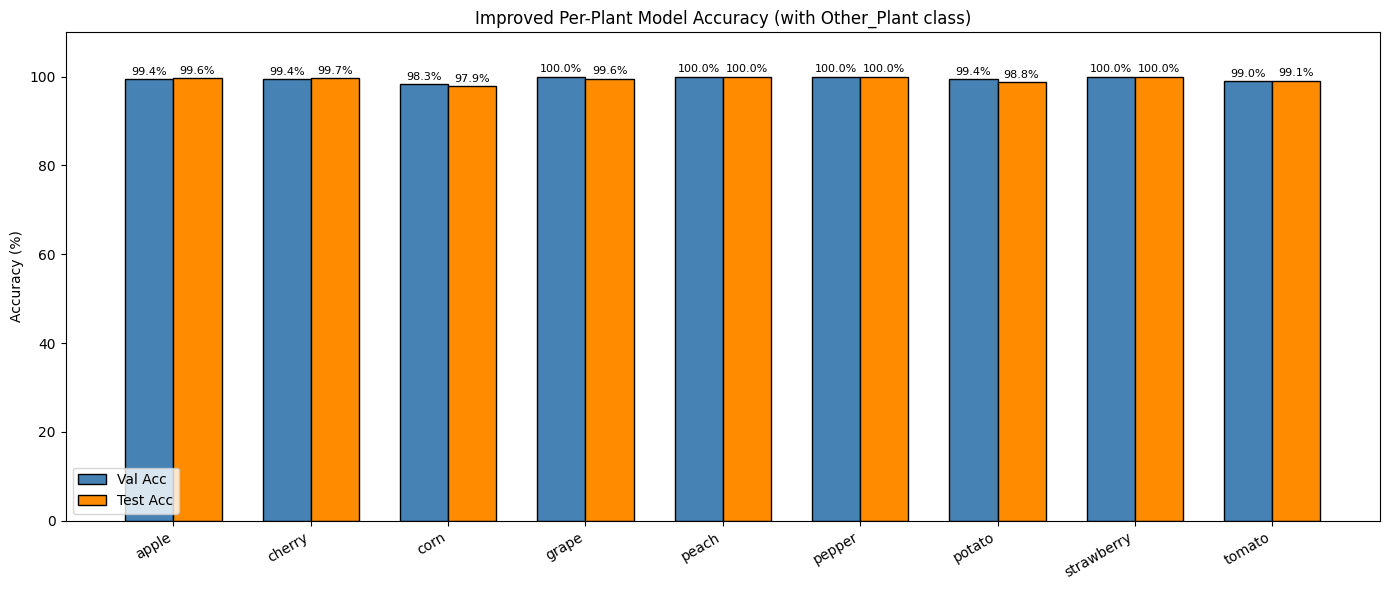

Chart saved: per_plant_models_v2/v2_accuracy_comparison.png


In [10]:
# Show results

print(f"{'Plant':<14} {'Classes':>9} {'Val Acc':>10} {'Test Acc':>10}")
print("-" * 47)
for name, info in summary.items():
    print(f"{name:<14} {info['num_classes']:>9} {info['val_acc']:>9.2f}% {info['test_acc']:>9.2f}%")

plants   = list(summary.keys())
val_accs = [summary[p]["val_acc"]  for p in plants]
test_accs= [summary[p]["test_acc"] for p in plants]

x = np.arange(len(plants))
w = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - w/2, val_accs,  w, label="Val Acc",  color="steelblue",  edgecolor="black")
b2 = ax.bar(x + w/2, test_accs, w, label="Test Acc", color="darkorange", edgecolor="black")

ax.set_ylabel("Accuracy (%)")
ax.set_title("Improved Per-Plant Model Accuracy (with Other_Plant class)")
ax.set_xticks(x)
ax.set_xticklabels(plants, rotation=30, ha="right")
ax.legend()
ax.set_ylim(0, 110)

for b in [*b1, *b2]:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
chart_path = os.path.join(SAVE_DIR, "v2_accuracy_comparison.png")
plt.savefig(chart_path, dpi=150)
plt.show()
print(f"Chart saved: {chart_path}")

In [11]:

api_snippet = '''
DROPOUT = 0.30  

def build_resnet(num_classes: int):
    """Build ResNet-18 with Dropout — matches v2 training architecture."""
    m = models.resnet18(weights=None)
        nn.Dropout(p=DROPOUT),
        nn.Linear(m.fc.in_features, num_classes)
    )
    return m
'''

print("Copy this into api/main.py, replacing the existing build_resnet function:")
print(api_snippet)

api_snippet2 = '''
raw_class = label_map[str(pred_idx)]
if "Other_Plant" in raw_class or "other_plant" in raw_class.lower():
    return {
        "status": "wrong_plant",
        "message": f"The leaf does not look like a {plant.capitalize()} leaf.",
        "confidence": round(plant_conf * 100, 2),
        "selected_plant": plant.capitalize()
    }
'''

print("Also add this check in the /predict endpoint:")
print(api_snippet2)

Copy this into api/main.py, replacing the existing build_resnet function:

DROPOUT = 0.30   # must match what was used during training

def build_resnet(num_classes: int):
    """Build ResNet-18 with Dropout — matches v2 training architecture."""
    m = models.resnet18(weights=None)
    m.fc = nn.Sequential(
        nn.Dropout(p=DROPOUT),
        nn.Linear(m.fc.in_features, num_classes)
    )
    return m

Also add this check in the /predict endpoint:

# Inside the /predict endpoint, after Layer 2 model runs:
raw_class = label_map[str(pred_idx)]
if "Other_Plant" in raw_class or "other_plant" in raw_class.lower():
    return {
        "status": "wrong_plant",
        "message": f"The leaf does not look like a {plant.capitalize()} leaf.",
        "confidence": round(plant_conf * 100, 2),
        "selected_plant": plant.capitalize()
    }

